In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras import callbacks

In [ ]:
train_path = '/content/drive/MyDrive/Brain_tumor/Training'
test_path = '/content/drive/MyDrive/Brain_tumor/Testing'

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    seed = 1,
    image_size = (224,224),
    batch_size = 32,
    shuffle = True,
    label_mode = 'categorical',
    subset = 'training',
    validation_split = 0.1
)

Found 5600 files belonging to 4 classes.
Using 5040 files for training.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    seed = 1,
    image_size = (224,224),
    batch_size = 32,
    shuffle = True,
    label_mode = 'categorical',
    subset = 'validation',
    validation_split = 0.1
)

Found 5600 files belonging to 4 classes.
Using 560 files for validation.


In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    seed = 1,
    image_size = (224,224),
    batch_size = 32,
    shuffle = False,
    label_mode = 'categorical'
)

Found 1600 files belonging to 4 classes.


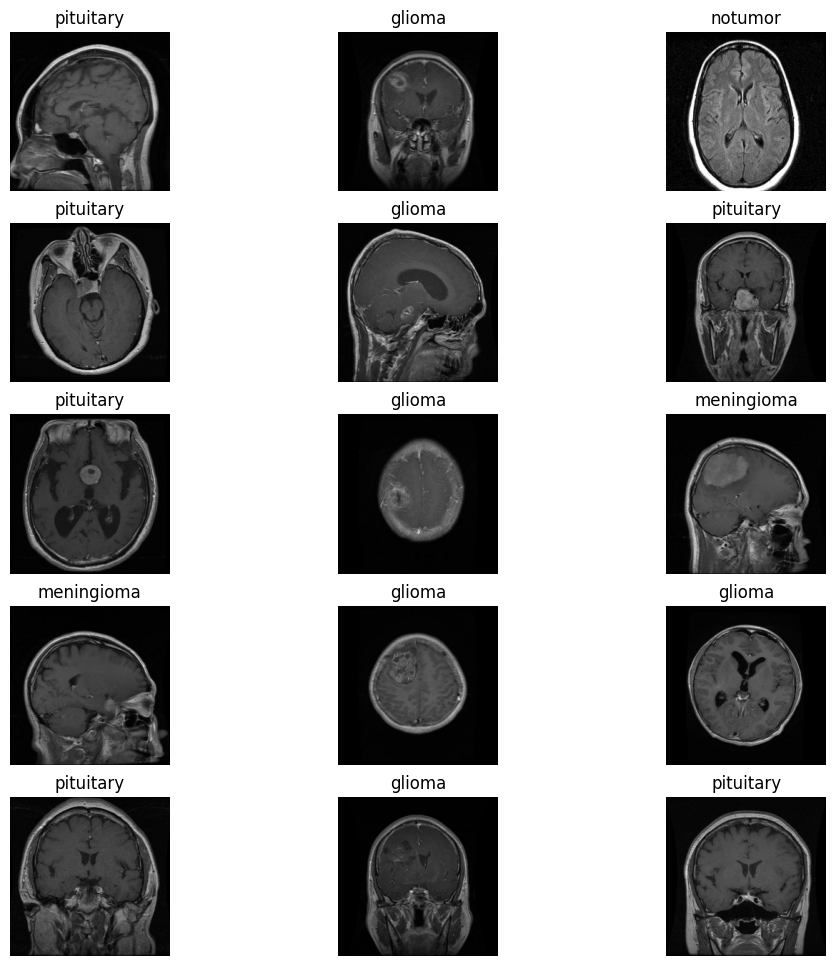

In [ ]:
class_names = train_ds.class_names

plt.figure(figsize= (12,12))

for images, labels in train_ds.take(1):
  for i in range(15):
    plt.subplot(5,3, i+1)
    plt.imshow(images[i].numpy().astype('uint8'))
    label_index = np.argmax(labels[i].numpy())
    plt.title(class_names[label_index])
    plt.axis('off')
plt.show()

In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds   = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y))

In [ ]:
# building efficient net for transfer learning
effnet = EfficientNetB1(
    include_top = False,
    weights = 'imagenet',
    input_shape = (224,224,3),
)

In [ ]:
model = effnet.output
model = tf.keras.layers.GlobalAveragePooling2D()(model)
model = tf.keras.layers.Dropout(0.3)(model)
model = tf.keras.layers.Dense(4, activation='softmax')(model)
model = tf.keras.models.Model(inputs=effnet.input, outputs=model)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 6,580,363 (25.10 MB)

 Trainable params: 6,518,308 (24.87 MB)

 Non-trainable params: 62,055 (242.41 KB)

In [ ]:
model.compile(
    loss='categorical_crossentropy',
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

In [ ]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/Brain_tumorbest_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

In [ ]:
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=1,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[checkpoint_cb, early_stopping]
)

Epoch 1/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 667ms/step - accuracy: 0.7550 - auc: 0.9208 - loss: 0.6469 - precision: 0.8535 - recall: 0.5955
Epoch 1: val_loss improved from None to 0.18256, saving model to /content/drive/MyDrive/Brain_tumorbest_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Brain_tumorbest_model.keras
158/158 ━━━━━━━━━━━━━━━━━━━━ 279s 808ms/step - accuracy: 0.8647 - auc: 0.9769 - loss: 0.3866 - precision: 0.9201 - recall: 0.7972 - val_accuracy: 0.9429 - val_auc: 0.9956 - val_loss: 0.1826 - val_precision: 0.9505 - val_recall: 0.9250
Epoch 2/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.9603 - auc: 0.9973 - loss: 0.1295 - precision: 0.9667 - recall: 0.9537
Epoch 2: val_loss improved from 0.18256 to 0.13429, saving model to /content/drive/MyDrive/Brain_tumorbest_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Brain_tumorbest_model.keras
158/158 ━━━━━━━━━━━━━━━━━━━━ 39s 247ms/step - accuracy: 0.9649 - auc: 0.9981 - l

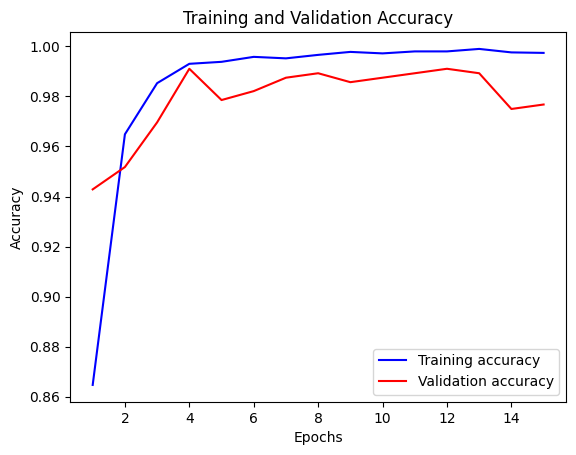

In [ ]:
import matplotlib.pyplot as plt

# 2. Extract accuracy values
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(acc) + 1)

# 3. Plot the data using Matplotlib
plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

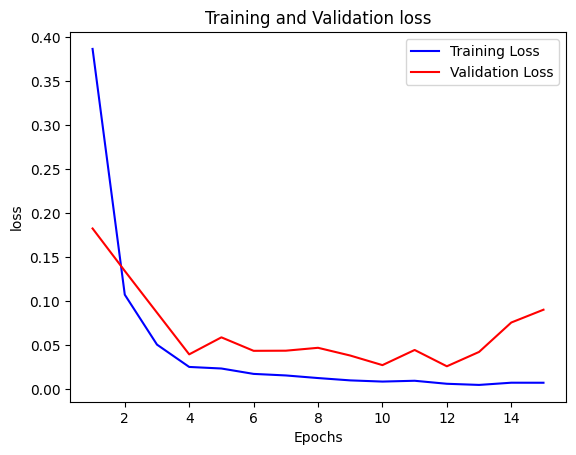

In [ ]:
acc = history.history['loss']
val_acc = history.history['val_loss']
epochs = range(1, len(acc) + 1)

# 3. Plot the data using Matplotlib
plt.plot(epochs, acc, 'b', label='Training Loss')
plt.plot(epochs, val_acc, 'r', label='Validation Loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

Found 1600 files belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 124ms/step


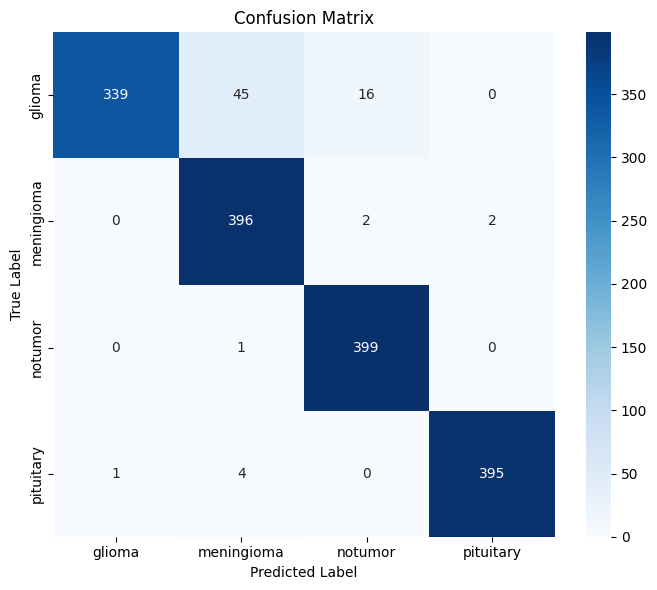

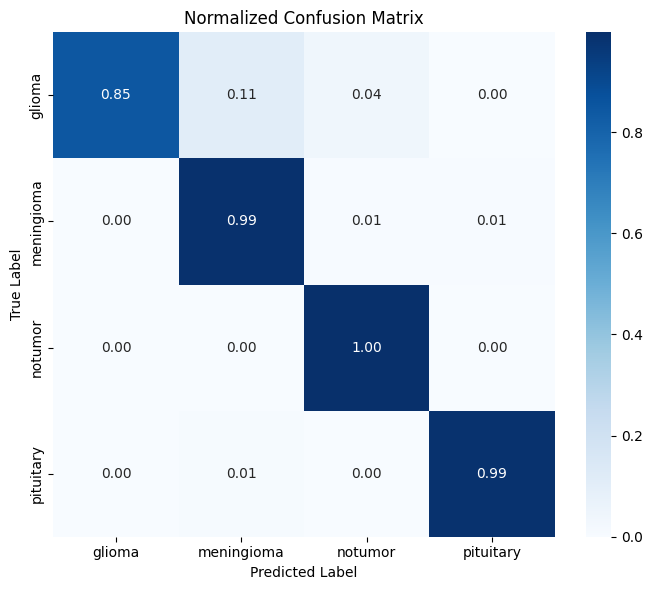

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

model = tf.keras.models.load_model("/content/drive/MyDrive/Brain_tumorbest_model.keras")


temp_ds = tf.keras.utils.image_dataset_from_directory(test_path)
class_names = temp_ds.class_names


y_pred = model.predict(test_ds)
y_pred = np.argmax(y_pred, axis=1)


y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_true = np.argmax(y_true, axis=1)

cm = confusion_matrix(y_true, y_pred)


plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")

plt.tight_layout()
plt.show()

In [ ]:
import shutil

# Change path from folder_a to folder_b
shutil.move("/content/drive/MyDrive/Brain_tumorbest_model.keras", "/content/drive/MyDrive/Brain_tumor")

'/content/drive/MyDrive/Brain_tumor/Brain_tumorbest_model.keras'

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(test_ds)
y_pred = np.argmax(y_pred, axis = 1)


y_true = np.concatenate([y for x, y in test_ds], axis = 0)
y_true = np.argmax(y_true, axis = 1)

accuracy = accuracy_score(y_true, y_pred)
print(f"\n Overall Accuracy: {accuracy:.4f}")


#Classification report
report = classification_report(
    y_true,
    y_pred,
    target_names = class_names,
    digits = 4
)

print("\n classification report")
print(report)

50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 256ms/step

 Overall Accuracy: 0.9556

 classification report
              precision    recall  f1-score   support

      glioma     0.9971    0.8475    0.9162       400
  meningioma     0.8879    0.9900    0.9362       400
     notumor     0.9568    0.9975    0.9767       400
   pituitary     0.9950    0.9875    0.9912       400

    accuracy                         0.9556      1600
   macro avg     0.9592    0.9556    0.9551      1600
weighted avg     0.9592    0.9556    0.9551      1600

